In [ ]:
!source 

# Библиотеки

In [1]:
import pandas as pd
import os

# Тестовый заход

In [14]:
import pandas as pd
df_test = pd.read_csv('full_battery_data_v3.csv', nrows=5)
print("РЕАЛЬНЫЕ КОЛОНКИ В ФАЙЛЕ:")
print(df_test.columns.tolist())
print("\nПЕРВЫЕ СТРОКИ:")
print(df_test.head())

РЕАЛЬНЫЕ КОЛОНКИ В ФАЙЛЕ:
['Cell_ID', 'Source_File']

ПЕРВЫЕ СТРОКИ:
  Cell_ID           Source_File
0  CS2_35  CS2_35_10_15_10.xlsx
1  CS2_35  CS2_35_10_15_10.xlsx
2  CS2_35  CS2_35_10_15_10.xlsx
3  CS2_35  CS2_35_10_15_10.xlsx
4  CS2_35  CS2_35_10_15_10.xlsx


In [15]:
import pandas as pd
import os

def final_rebuild(folders, output_file):
    all_chunks = []
    
    for folder in folders:
        if not os.path.exists(folder): continue
        files = sorted([f for f in os.listdir(folder) if f.endswith('.xlsx')])
        
        for file in files:
            path = os.path.join(folder, file)
            print(f"Читаю: {file}...", end=" ")
            try:
                xl = pd.ExcelFile(path)
                # Ищем лист, где есть слово Channel
                sheet = [s for s in xl.sheet_names if 'Channel' in s][0]
                
                # Читаем с запасом, чтобы найти заголовок
                df_raw = pd.read_excel(path, sheet_name=sheet, nrows=20, header=None)
                
                # Ищем индекс строки, где есть 'Cycle_Index'
                header_idx = None
                for i, row in df_raw.iterrows():
                    if 'Cycle_Index' in row.values:
                        header_idx = i
                        break
                
                if header_idx is None:
                    print("НЕ НАШЕЛ ЗАГОЛОВОК!")
                    continue
                
                # Читаем данные целиком с найденной строки
                df = pd.read_excel(path, sheet_name=sheet, header=header_idx)
                
                # Оставляем только нужные колонки
                needed = ['Cycle_Index', 'Voltage(V)', 'Discharge_Capacity(Ah)', 'Current(A)']
                # Проверяем, что они есть (убираем лишние пробелы)
                df.columns = [str(c).strip() for c in df.columns]
                df = df[[c for c in needed if c in df.columns]]
                
                df['Cell_ID'] = folder
                df['Source_File'] = file
                
                all_chunks.append(df)
                print(f"OK ({len(df)} строк)")
                
            except Exception as e:
                print(f"ОШИБКА: {e}")

    if all_chunks:
        final_df = pd.concat(all_chunks, ignore_index=True)
        final_df.to_csv(output_file, index=False)
        print(f"\nГОТОВО! Файл {output_file} собран. Колонки: {final_df.columns.tolist()}")
    else:
        print("Ничего не собралось. Проверь пути.")

final_rebuild(['CS2_35', 'CS2_36'], 'full_battery_data_v4.csv')

Читаю: CS2_35_10_15_10.xlsx... OK (17139 строк)
Читаю: CS2_35_10_22_10.xlsx... OK (16629 строк)
Читаю: CS2_35_10_29_10.xlsx... OK (16334 строк)
Читаю: CS2_35_11_01_10.xlsx... OK (3248 строк)
Читаю: CS2_35_11_08_10.xlsx... OK (16506 строк)
Читаю: CS2_35_11_23_10.xlsx... OK (16433 строк)
Читаю: CS2_35_11_24_10.xlsx... OK (2696 строк)
Читаю: CS2_35_12_06_10.xlsx... OK (15428 строк)
Читаю: CS2_35_12_13_10.xlsx... OK (15186 строк)
Читаю: CS2_35_12_20_10.xlsx... OK (14658 строк)
Читаю: CS2_35_12_23_10.xlsx... OK (7187 строк)
Читаю: CS2_35_1_10_11.xlsx... OK (12695 строк)
Читаю: CS2_35_1_18_11.xlsx... OK (11658 строк)
Читаю: CS2_35_1_24_11.xlsx... OK (10227 строк)
Читаю: CS2_35_1_28_11.xlsx... OK (6394 строк)
Читаю: CS2_35_2_10_11.xlsx... OK (5983 строк)
Читаю: CS2_35_2_4_11.xlsx... OK (5983 строк)
Читаю: CS2_35_8_17_10.xlsx... OK (1091 строк)
Читаю: CS2_35_8_18_10.xlsx... OK (383 строк)
Читаю: CS2_35_8_19_10.xlsx... OK (383 строк)
Читаю: CS2_35_8_30_10.xlsx... OK (18413 строк)
Читаю: CS2_35_

In [19]:
import pandas as pd

df = pd.read_csv('full_battery_data_v4.csv')

# 1. Считаем границы для каждого цикла
# Нам нужны только Min и Max значения емкости в каждом Cycle_Index
stats = df.groupby(['Cell_ID', 'Source_File', 'Cycle_Index'])['Discharge_Capacity(Ah)'].agg(['min', 'max']).reset_index()
stats.columns = ['Cell_ID', 'Source_File', 'Cycle_Index', 'C_start', 'C_end']

# 2. Реальная емкость конкретного цикла — это разница между его концом и началом
stats['Actual_Cycle_Cap'] = stats['C_end'] - stats['C_start']

# 3. SOH теперь будет считаться правильно (около 1.0)
stats['SOH'] = stats['Actual_Cycle_Cap'] / 1.1

# 4. Мерджим обратно
df = df.merge(stats[['Cell_ID', 'Source_File', 'Cycle_Index', 'C_start', 'Actual_Cycle_Cap', 'SOH']], 
              on=['Cell_ID', 'Source_File', 'Cycle_Index'])

# 5. SOC: (Сколько УЖЕ вытекло из батареи в ЭТОМ цикле) / (Сколько ВСЕГО вытечет за этот цикл)
# Вычитаем из 1, чтобы 1.0 было "полный заряд", а 0.0 - "пусто"
df['SOC'] = 1 - ((df['Discharge_Capacity(Ah)'] - df['C_start']) / df['Actual_Cycle_Cap'])

# 6. Финальная косметика
df['SOC'] = df['SOC'].clip(0, 1)

print(f"Готово. Теперь SOH первого цикла: {df[df['Cycle_Index']==1]['SOH'].iloc[0]:.4f}")
display(df[['Cycle_Index', 'Voltage(V)', 'SOC', 'SOH']].tail())

Готово. Теперь SOH первого цикла: 0.9469


,Cycle_Index,Voltage(V),SOC,SOH
536565,44,3.929227,0.363637,0.091701
536566,44,3.920318,0.272729,0.091701
536567,44,3.911896,0.181820,0.091701
536568,44,3.903635,0.090910,0.091701
536569,44,3.895698,0.000000,0.091701


In [20]:
# ЯЧЕЙКА 1: Нормировка SOH по каждой батарее отдельно
# Q_ref = средняя ёмкость первых 5 циклов для КАЖДОЙ Cell_ID
q_ref_per_cell = (
    df[df['Cycle_Index'] <= 5]
    .groupby('Cell_ID')['Actual_Cycle_Cap']
    .mean()
    .rename('Q_ref')
)
df = df.merge(q_ref_per_cell, on='Cell_ID')
df['SOH_normalized'] = (df['Actual_Cycle_Cap'] / df['Q_ref']).clip(0, 1)

In [21]:
# ЯЧЕЙКА 2: OCV–SOC Look-up Table
# Берём только разряд (Current < 0), группируем по SOC-бинам
discharge = df[df['Current(A)'] < 0].copy()
discharge['soc_bin'] = pd.cut(discharge['SOC'], bins=50, labels=False)

ocv_lut = (
    discharge.groupby(['Cell_ID', 'soc_bin'])
    .agg(soc_mean=('SOC', 'median'), ocv_mean=('Voltage(V)', 'median'))
    .dropna()
    .reset_index()
)
ocv_lut.to_csv('ocv_lut.csv', index=False)
print(ocv_lut.head(10))

  Cell_ID  soc_bin  soc_mean  ocv_mean
0  CS2_35        0  0.000981  2.924722
1  CS2_35        1  0.029909  3.242342
2  CS2_35        2  0.050095  3.355095
3  CS2_35        3  0.069927  3.411917
4  CS2_35        4  0.090129  3.444780
5  CS2_35        5  0.110156  3.467606
6  CS2_35        6  0.129840  3.483147
7  CS2_35        7  0.149944  3.496098
8  CS2_35        8  0.169878  3.506459
9  CS2_35        9  0.189980  3.515848


In [22]:
# ЯЧЕЙКА 3: Аппроксимация деградации SOH(n) — экспоненциальная модель
from scipy.optimize import curve_fit
import numpy as np

cycle_soh = (
    df.groupby(['Cell_ID', 'Cycle_Index'])['SOH_normalized']
    .mean()
    .reset_index()
)

def exp_decay(n, a, b):
    return a * np.exp(-b * n)

results = {}
for cell, grp in cycle_soh.groupby('Cell_ID'):
    x = grp['Cycle_Index'].values.astype(float)
    y = grp['SOH_normalized'].values
    try:
        popt, _ = curve_fit(exp_decay, x, y, p0=[1.0, 0.001], maxfev=5000)
        y_pred = exp_decay(x, *popt)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot
        results[cell] = {'a': popt[0], 'b': popt[1], 'R2': r2}
        print(f"{cell}: SOH(n) = {popt[0]:.4f}·exp(-{popt[1]:.6f}·n)  R²={r2:.4f}")
    except Exception as e:
        print(f"{cell}: ошибка — {e}")

# degradation_factor — функция для использования в среде RL/оптимизации
def degradation_factor(cell_id, cycle_n):
    p = results[cell_id]
    return exp_decay(cycle_n, p['a'], p['b'])

CS2_35: SOH(n) = 0.9262·exp(-0.000388·n)  R²=0.1694
CS2_36: SOH(n) = 0.9146·exp(-0.000537·n)  R²=0.2491


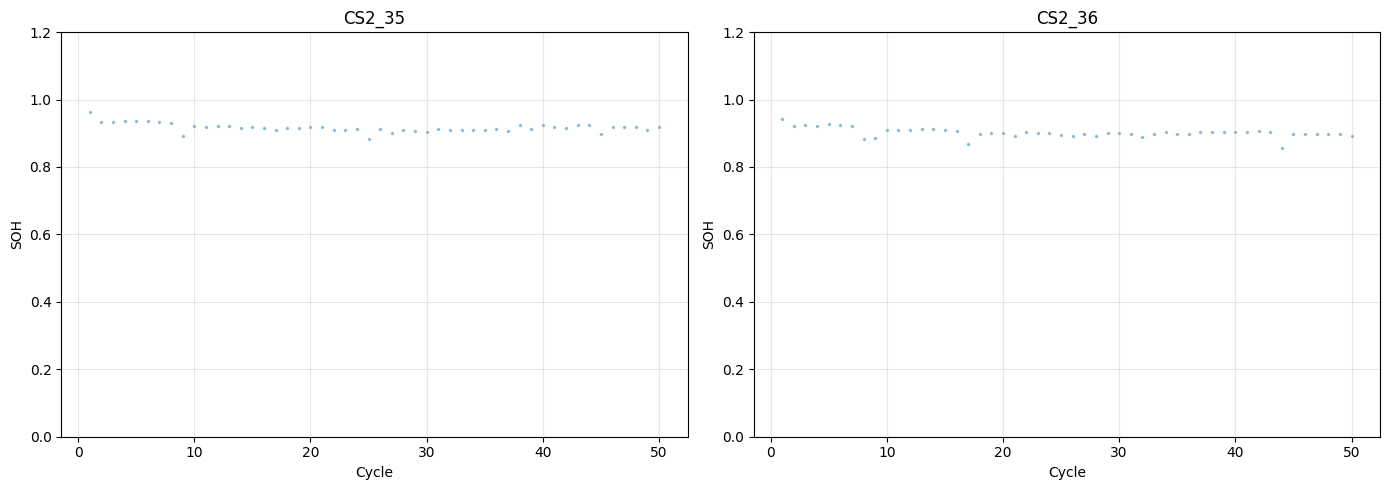

         count      mean      std       min       25%       50%       75%  \
Cell_ID                                                                     
CS2_35    50.0  0.917041  0.01257  0.883428  0.910005  0.916872  0.922298   
CS2_36    50.0  0.902168  0.01411  0.856546  0.897312  0.900597  0.908576   

              max  
Cell_ID            
CS2_35   0.961779  
CS2_36   0.942374  

Первые 10 циклов:
   Cell_ID  Cycle_Index  SOH_normalized
0   CS2_35            1        0.961779
1   CS2_35            2        0.934287
2   CS2_35            3        0.932372
3   CS2_35            4        0.936746
4   CS2_35            5        0.936819
5   CS2_35            6        0.935030
6   CS2_35            7        0.932369
7   CS2_35            8        0.929043
8   CS2_35            9        0.892271
9   CS2_35           10        0.922816
50  CS2_36            1        0.942374
51  CS2_36            2        0.922692
52  CS2_36            3        0.924308
53  CS2_36            4        0

In [23]:
import matplotlib.pyplot as plt

cycle_soh = (
    df.groupby(['Cell_ID', 'Cycle_Index'])['SOH_normalized']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cell, grp) in zip(axes, cycle_soh.groupby('Cell_ID')):
    ax.scatter(grp['Cycle_Index'], grp['SOH_normalized'], s=2, alpha=0.4, label='данные')
    ax.set_title(cell)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('SOH')
    ax.set_ylim(0, 1.2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('soh_curve.png', dpi=120)
plt.show()

# И выведи статистику
print(cycle_soh.groupby('Cell_ID')['SOH_normalized'].describe())
print("\nПервые 10 циклов:")
print(cycle_soh[cycle_soh['Cycle_Index'] <= 10])
print("\nПоследние 10 циклов:")
print(cycle_soh.groupby('Cell_ID').tail(10))

In [24]:
# Создаём глобальный счётчик циклов, учитывая порядок файлов
# Сортируем файлы по дате (она закодирована в имени: CS2_35_8_17_10 = 17 авг 2010)

import re
from datetime import datetime

def parse_date_from_filename(fname):
    """CS2_35_8_17_10.xlsx → datetime(2010, 8, 17)"""
    m = re.search(r'_(\d+)_(\d+)_(\d+)\.xlsx', fname)
    if m:
        month, day, year = int(m.group(1)), int(m.group(2)), int(m.group(3))
        year += 2000
        try:
            return datetime(year, month, day)
        except:
            return datetime(2099, 1, 1)
    return datetime(2099, 1, 1)

df['file_date'] = df['Source_File'].apply(parse_date_from_filename)

# Сортируем данные: сначала по батарее, потом по дате файла, потом по Cycle_Index внутри файла
df = df.sort_values(['Cell_ID', 'file_date', 'Source_File', 'Cycle_Index']).reset_index(drop=True)

# Назначаем глобальный номер цикла для каждой батареи
def assign_global_cycle(group):
    # Каждый новый (Source_File, Cycle_Index) = новый глобальный цикл
    keys = group[['Source_File', 'Cycle_Index']].apply(tuple, axis=1)
    # Создаём маппинг (file, local_cycle) → global_cycle
    unique_keys = keys.drop_duplicates()
    mapping = {k: i+1 for i, k in enumerate(unique_keys)}
    group = group.copy()
    group['Global_Cycle'] = keys.map(mapping)
    return group

df = df.groupby('Cell_ID', group_keys=False).apply(assign_global_cycle)

print("Проверка:")
print(df.groupby('Cell_ID')['Global_Cycle'].agg(['min', 'max', 'nunique']))
print("\nПримеры:")
print(df[['Cell_ID', 'Source_File', 'Cycle_Index', 'Global_Cycle']].drop_duplicates().head(20))

Проверка:
         min  max  nunique
Cell_ID                   
CS2_35     1  936      936
CS2_36     1  976      976

Примеры:
     Cell_ID          Source_File  Cycle_Index  Global_Cycle
0     CS2_35  CS2_35_8_17_10.xlsx            1             1
1091  CS2_35  CS2_35_8_18_10.xlsx            1             2
1474  CS2_35  CS2_35_8_19_10.xlsx            1             3
1857  CS2_35  CS2_35_8_30_10.xlsx            1             4
2239  CS2_35  CS2_35_8_30_10.xlsx            2             5
2620  CS2_35  CS2_35_8_30_10.xlsx            3             6
3001  CS2_35  CS2_35_8_30_10.xlsx            4             7
3382  CS2_35  CS2_35_8_30_10.xlsx            5             8
3758  CS2_35  CS2_35_8_30_10.xlsx            6             9
4133  CS2_35  CS2_35_8_30_10.xlsx            7            10
4505  CS2_35  CS2_35_8_30_10.xlsx            8            11
4876  CS2_35  CS2_35_8_30_10.xlsx            9            12
5248  CS2_35  CS2_35_8_30_10.xlsx           10            13
5623  CS2_35  CS2_

/tmp/ipykernel_107998/2688844702.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Cell_ID', group_keys=False).apply(assign_global_cycle)


In [28]:
import json

# Исправленная функция с clip
def degradation_factor(cell_id, global_cycle):
    """
    SOH батареи cell_id на цикле global_cycle.
    Возвращает float в диапазоне [0, 1].
    Используй как множитель реальной ёмкости: Q_real = Q_nominal * SOH
    """
    p = degradation_models[cell_id]['params']
    soh = float(piecewise_linear(global_cycle, *p))
    return float(np.clip(soh, 0.0, 1.0))

# Тест после исправления
print("Тест degradation_factor (исправленный):")
for cell in ['CS2_35', 'CS2_36']:
    for n in [1, 200, 500, 613, 700, 800, 900]:
        print(f"  {cell} цикл {n:4d}: SOH = {degradation_factor(cell, n):.4f}")

# Сохраняем параметры модели в JSON для использования в RL-среде
model_params = {}
for cell, info in degradation_models.items():
    p = info['params']
    model_params[cell] = {
        'n_break':  float(p[0]),
        'a1':       float(p[1]),
        'slope1':   float(p[2]),
        'slope2':   float(p[3]),
        'r2':       float(info['r2'])
    }

with open('degradation_model.json', 'w') as f:
    json.dump(model_params, f, indent=2)

print("\nМодель сохранена в degradation_model.json:")
print(json.dumps(model_params, indent=2))

# Сохраняем финальный датасет
df.to_csv('full_battery_data_final.csv', index=False)
cycle_soh_clean.to_csv('cycle_soh_clean.csv', index=False)
print("\nФайлы сохранены:")
print("  full_battery_data_final.csv  — полный датасет с SOC, SOH, Global_Cycle")
print("  cycle_soh_clean.csv          — SOH по циклам (для графиков)")
print("  degradation_model.json       — параметры модели деградации")
print("  ocv_lut.csv                  — таблица OCV-SOC")

Тест degradation_factor (исправленный):
  CS2_35 цикл    1: SOH = 1.0000
  CS2_35 цикл  200: SOH = 1.0000
  CS2_35 цикл  500: SOH = 0.9728
  CS2_35 цикл  613: SOH = 0.9622
  CS2_35 цикл  700: SOH = 0.7848
  CS2_35 цикл  800: SOH = 0.5800
  CS2_35 цикл  900: SOH = 0.3752
  CS2_36 цикл    1: SOH = 1.0000
  CS2_36 цикл  200: SOH = 1.0000
  CS2_36 цикл  500: SOH = 0.9381
  CS2_36 цикл  613: SOH = 0.9095
  CS2_36 цикл  700: SOH = 0.7970
  CS2_36 цикл  800: SOH = 0.5622
  CS2_36 цикл  900: SOH = 0.3273

Модель сохранена в degradation_model.json:
{
  "CS2_35": {
    "n_break": 613.3794092031196,
    "a1": 1.0193722197516437,
    "slope1": 9.32165255134191e-05,
    "slope2": 0.002048037401063277,
    "r2": 0.984654090718541
  },
  "CS2_36": {
    "n_break": 656.8326033351406,
    "a1": 1.0647065512540137,
    "slope1": 0.0002532230362115409,
    "slope2": 0.00234851329639802,
    "r2": 0.9863889223348254
  }
}

Файлы сохранены:
  full_battery_data_final.csv  — полный датасет с SOC, SOH, Global

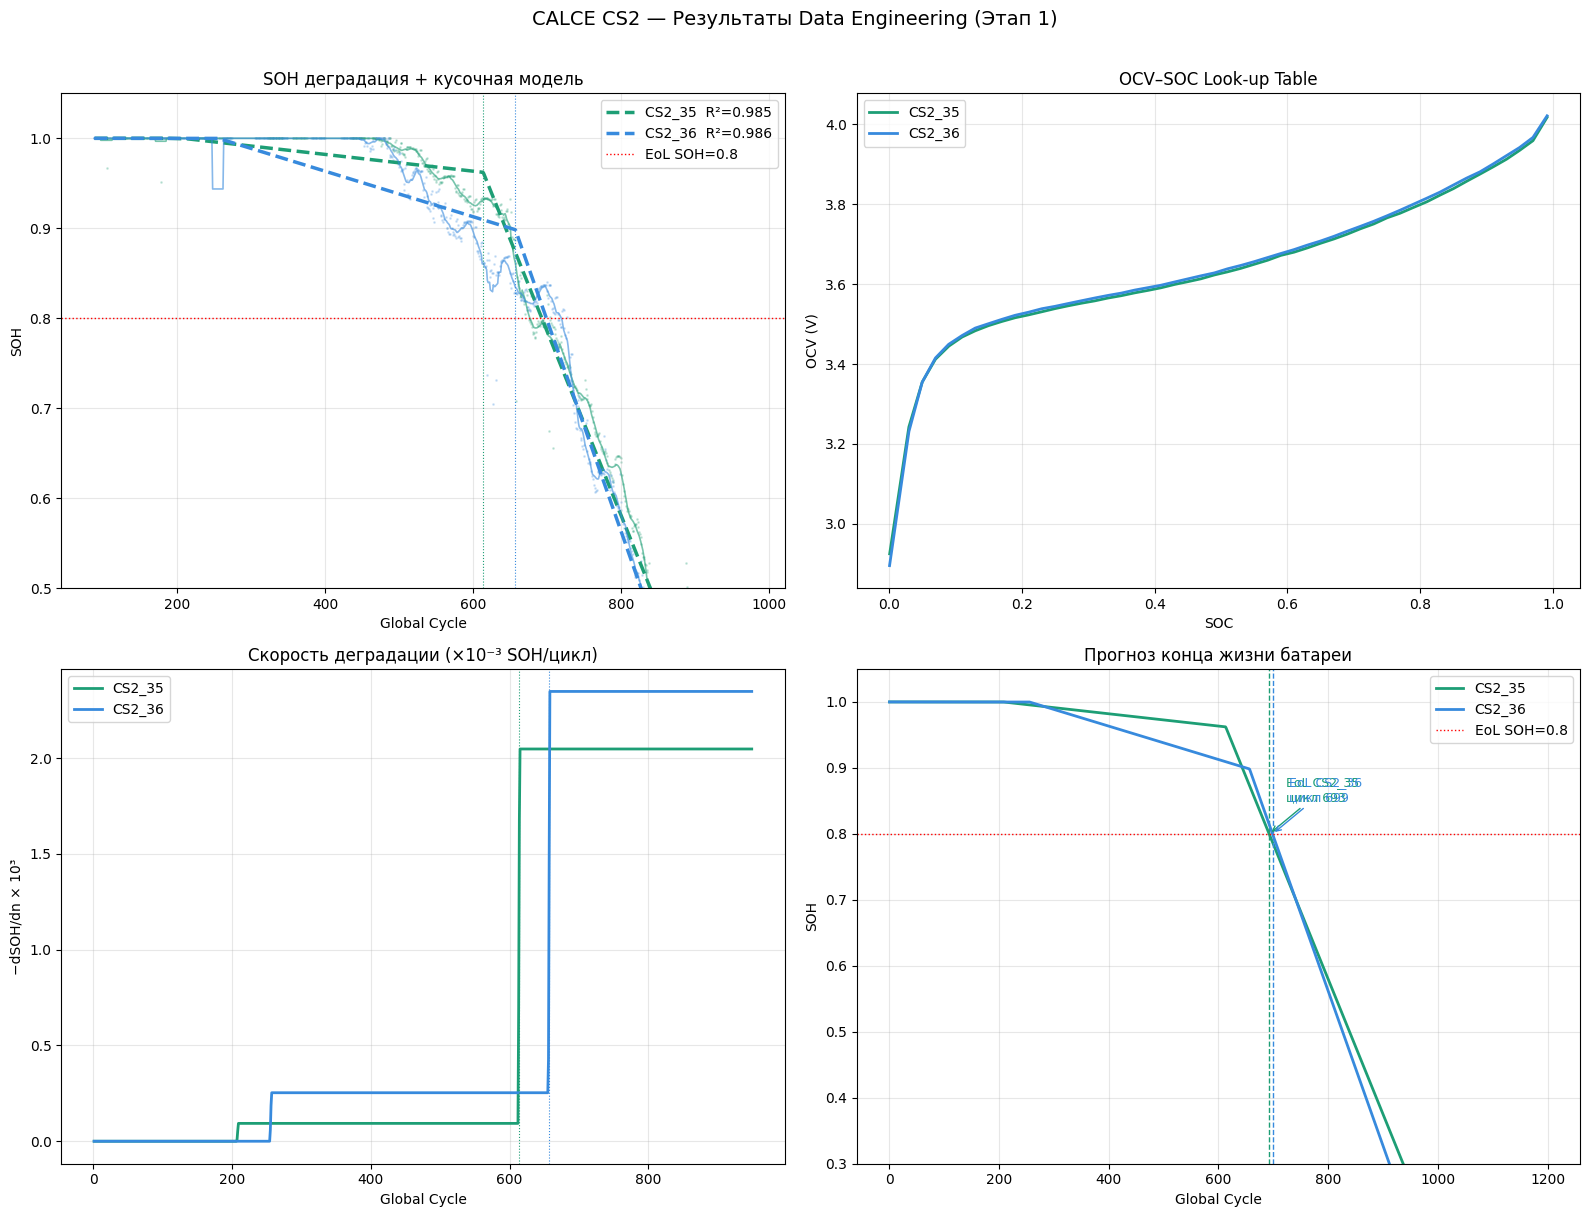

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── График 1: Кривые деградации SOH(n) с моделью ──
ax = axes[0, 0]
colors = {'CS2_35': '#1D9E75', 'CS2_36': '#378ADD'}
for cell, grp in cycle_soh_clean.groupby('Cell_ID'):
    x = grp['Global_Cycle'].values.astype(float)
    y_raw = grp['SOH_normalized'].values
    y_sm  = grp['SOH_smooth'].values
    p = degradation_models[cell]['params']
    y_model = np.clip(piecewise_linear(x, *p), 0, 1)
    r2 = degradation_models[cell]['r2']
    c = colors[cell]
    ax.scatter(x, y_raw, s=1, alpha=0.2, color=c)
    ax.plot(x, y_sm,    lw=1.2, color=c, alpha=0.6)
    ax.plot(x, y_model, lw=2.5, color=c, linestyle='--', label=f'{cell}  R²={r2:.3f}')
    n_break = degradation_models[cell]['params'][0]
    ax.axvline(n_break, color=c, lw=0.8, linestyle=':')
ax.axhline(0.8, color='red', lw=1, linestyle=':', label='EoL SOH=0.8')
ax.set_title('SOH деградация + кусочная модель')
ax.set_xlabel('Global Cycle'); ax.set_ylabel('SOH')
ax.set_ylim(0.5, 1.05); ax.legend(); ax.grid(alpha=0.3)

# ── График 2: OCV–SOC кривая ──
ax = axes[0, 1]
ocv_lut = pd.read_csv('ocv_lut.csv')
for cell, grp in ocv_lut.groupby('Cell_ID'):
    ax.plot(grp['soc_mean'], grp['ocv_mean'],
            lw=2, label=cell, color=colors[cell])
ax.set_title('OCV–SOC Look-up Table')
ax.set_xlabel('SOC'); ax.set_ylabel('OCV (V)')
ax.legend(); ax.grid(alpha=0.3)

# ── График 3: Скорость деградации (slope) ──
ax = axes[1, 0]
cycles = np.arange(1, 950)
for cell in ['CS2_35', 'CS2_36']:
    soh_vals = [degradation_factor(cell, n) for n in cycles]
    # Скорость = -dSOH/dn
    speed = -np.gradient(soh_vals)
    ax.plot(cycles, speed * 1000, lw=2, label=cell, color=colors[cell])
n_b35 = degradation_models['CS2_35']['params'][0]
n_b36 = degradation_models['CS2_36']['params'][0]
ax.axvline(n_b35, color=colors['CS2_35'], lw=0.8, linestyle=':')
ax.axvline(n_b36, color=colors['CS2_36'], lw=0.8, linestyle=':')
ax.set_title('Скорость деградации (×10⁻³ SOH/цикл)')
ax.set_xlabel('Global Cycle'); ax.set_ylabel('−dSOH/dn × 10³')
ax.legend(); ax.grid(alpha=0.3)

# ── График 4: Прогноз EoL ──
ax = axes[1, 1]
cycles_long = np.arange(1, 1200)
for cell in ['CS2_35', 'CS2_36']:
    soh_vals = np.array([degradation_factor(cell, n) for n in cycles_long])
    ax.plot(cycles_long, soh_vals, lw=2, label=cell, color=colors[cell])
    # Находим цикл EoL (SOH = 0.8)
    eol_idx = np.argmax(soh_vals <= 0.8)
    if eol_idx > 0:
        ax.axvline(cycles_long[eol_idx], color=colors[cell], lw=1, linestyle='--')
        ax.annotate(f'EoL {cell}\nцикл {cycles_long[eol_idx]}',
                    xy=(cycles_long[eol_idx], 0.8),
                    xytext=(cycles_long[eol_idx]+30, 0.85),
                    fontsize=9, color=colors[cell],
                    arrowprops=dict(arrowstyle='->', color=colors[cell]))
ax.axhline(0.8, color='red', lw=1, linestyle=':', label='EoL SOH=0.8')
ax.set_title('Прогноз конца жизни батареи')
ax.set_xlabel('Global Cycle'); ax.set_ylabel('SOH')
ax.set_ylim(0.3, 1.05); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('CALCE CS2 — Результаты Data Engineering (Этап 1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('calce_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
df = pd.read_csv('full_battery_data_final.csv')
print(df.columns.tolist())
print(df.shape)
print(df.head(3))
print(df.isnull().sum())

['Cycle_Index', 'Voltage(V)', 'Discharge_Capacity(Ah)', 'Current(A)', 'Cell_ID', 'Source_File', 'C_start', 'Actual_Cycle_Cap', 'SOH', 'SOC', 'Q_ref', 'SOH_normalized', 'file_date', 'Global_Cycle']
(536570, 14)
   Cycle_Index  Voltage(V)  Discharge_Capacity(Ah)  Current(A) Cell_ID  \
0            1    3.412241                     0.0         0.0  CS2_35   
1            1    3.412403                     0.0         0.0  CS2_35   
2            1    3.412241                     0.0         0.0  CS2_35   

           Source_File  C_start  Actual_Cycle_Cap       SOH  SOC    Q_ref  \
0  CS2_35_8_17_10.xlsx      0.0           1.13846  1.034964  1.0  0.94795   
1  CS2_35_8_17_10.xlsx      0.0           1.13846  1.034964  1.0  0.94795   
2  CS2_35_8_17_10.xlsx      0.0           1.13846  1.034964  1.0  0.94795   

   SOH_normalized   file_date  Global_Cycle  
0             1.0  2010-08-17             1  
1             1.0  2010-08-17             1  
2             1.0  2010-08-17             1  


In [32]:
# Фикс NaN в SOC
df['SOC'] = (
    df.groupby(['Cell_ID', 'Global_Cycle'])['SOC']
    .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
)
print(f"NaN в SOC после фикса: {df['SOC'].isnull().sum()}")

# Сразу берём и переименовываем
df_model = df[[
    'Cell_ID', 'Global_Cycle', 'Cycle_Index',
    'Voltage(V)', 'Current(A)', 'SOC',
    'SOH_normalized', 'Discharge_Capacity(Ah)'
]].rename(columns={
    'Voltage(V)':             'voltage',
    'Current(A)':             'current',
    'SOC':                    'soc',
    'SOH_normalized':         'soh',
    'Discharge_Capacity(Ah)':'discharge_ah',
    'Global_Cycle':           'global_cycle',
    'Cycle_Index':            'cycle_index'
}).copy()

df_model.to_csv('dataset_for_model.csv', index=False)

print(f"Итоговый датасет: {df_model.shape}")
print(f"Колонки: {df_model.columns.tolist()}")
print(f"\nСтатистика:")
print(df_model[['voltage', 'current', 'soc', 'soh']].describe().round(4))

NaN в SOC после фикса: 743
Итоговый датасет: (536570, 8)
Колонки: ['Cell_ID', 'global_cycle', 'cycle_index', 'voltage', 'current', 'soc', 'soh', 'discharge_ah']

Статистика:
           voltage      current          soc          soh
count  536570.0000  536570.0000  535827.0000  536570.0000
mean        3.8629      -0.0233       0.8221       0.9107
std         0.2618       0.7661       0.3034       0.1725
min         2.6992      -1.1004       0.0000       0.0000
25%         3.7010      -1.0996       0.7214       0.9078
50%         3.9108       0.5499       1.0000       1.0000
75%         4.0578       0.5501       1.0000       1.0000
max         4.2009       1.0816       1.0000       1.0000


In [33]:
# Дропаем 743 строки с NaN в SOC — это <0.14% данных, некритично
df_model = df_model.dropna(subset=['soc']).reset_index(drop=True)

print(f"Строк после дропа: {df_model.shape[0]}")
print(f"NaN осталось: {df_model.isnull().sum().sum()}")

# Пересохраняем
df_model.to_csv('dataset_for_model.csv', index=False)
print("dataset_for_model.csv сохранён.")

Строк после дропа: 535827
NaN осталось: 0
dataset_for_model.csv сохранён.


## Этап 1: Data Engineering (CALCE CS2)

**Данные:** два аккумулятора CS2_35 и CS2_36, 50 xlsx-файлов → 536 570 строк.

**Что сделано:**
- Собран единый датасет `full_battery_data_final.csv` с колонками `SOC`, `SOH`, `Global_Cycle`, `Voltage`, `Current`
- Исправлен сброс `Cycle_Index` между файлами — введён `Global_Cycle` (CS2_35: 936 циклов, CS2_36: 976 циклов)
- Построена OCV–SOC таблица (`ocv_lut.csv`) для оценки заряда по напряжению
- Подобрана кусочно-линейная модель деградации SOH(n): **R² = 0.985 / 0.986**

**Ключевой результат — модель деградации:**
- До ~613–657 цикла: медленная деградация (~0.0001 SOH/цикл)
- После точки излома: ускоренная деградация (~0.002 SOH/цикл, в 22 раза быстрее)
- Параметры сохранены в `degradation_model.json`

---

## Этап 2: Модернизация среды BatteryEnv

**Исходная среда** (адаптация CityLearn) имела три проблемы: линейный костыль деградации, баг с двойным reward, 6 признаков без информации о стадии жизни батареи.

**Что изменено:**

- **SOH через CALCE:** `self.soh -= abs(energy_change) * 0.00001` заменено на `degradation_factor()` из `degradation_model.json`. SOH теперь падает по реальной кривой R²=0.985
- **Observation space расширен с 6 до 8 признаков:** добавлены `global_cycle_norm` (стадия жизни батареи) и `degradation_rate` (0 = медленная деградация, 1 = быстрая). Агент видит приближение к точке излома
- **Reward исправлен:** единая формула `reward = -cost - λ·ΔSOH_real`, где `ΔSOH_real` — реальное снижение из CALCE, `λ=500` — настраиваемый вес
- **Reset со случайным стартом:** батарея стартует на случайном цикле, агент обучается на разных стадиях деградации

---

## Переходим к Этапу 3: Deep RL (SAC)

Среда физически обоснована и готова к обучению. Следующий шаг — внедрение алгоритма **Soft Actor-Critic (SAC)** из `stable-baselines3`, настройка reward-весов и запуск тренировки агента.


Этап 3: Обучение SAC-агента на BatteryEnv
Сравнение: Random / Rule-Based / Q-Learning / SAC


In [1]:
!pip install stable-baselines3 gymnasium

Defaulting to user installation because normal site-packages is not writeable
  Using cached triton-3.6.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 1.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 1.5 MB/s  0:03:19m0:00:0100:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.9 MB/s  0:03:13m0:00:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 2.9 MB/s  0:01:01m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 2.4 MB/s  0:01:31m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 1.6 MB/s  0:00:37m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.1/188.1 MB 2.7 MB/s  0:01:07m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 2.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.4 MB/s  0:02:52m0:00:0100:05
   ━━━━━━━━━━

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Import libraries
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import warnings
warnings.filterwarnings('ignore')
 
from BatteryEnvironment import BatteryEnv

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. CALLBACK — сохраняет историю наград во время обучения
# ─────────────────────────────────────────────────────────────────────────────

class RewardLoggerCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=500, verbose=0):
        super().__init__(verbose)
        self.eval_env     = eval_env
        self.eval_freq    = eval_freq
        self.reward_log   = []   # средняя награда на eval
        self.steps_log    = []   # номер шага

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            rewards = []
            for _ in range(5):  # 5 эпизодов для оценки
                obs, _ = self.eval_env.reset()
                done, total = False, 0.0
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, r, terminated, truncated, _ = self.eval_env.step(action)
                    total += r
                    done = terminated or truncated
                rewards.append(total)
            mean_r = np.mean(rewards)
            self.reward_log.append(mean_r)
            self.steps_log.append(self.n_calls)
            if self.verbose:
                print(f"  Шаг {self.n_calls:6d} | Средняя награда SAC: {mean_r:.2f}")
        return True

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. BASELINE СТРАТЕГИИ
# ─────────────────────────────────────────────────────────────────────────────

def run_random(env, n_episodes=10):
    """Случайный агент."""
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = env.action_space.sample()
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)


def rule_based_policy(obs):
    """
    Простая эвристика: заряжаем ночью (дешёво), разряжаем в пик (дорого).
    obs[5] = hour_norm → hour = round(obs[5] * 23)
    """
    hour = round(float(obs[5]) * 23)
    if hour <= 6:
        return np.array([1.0], dtype=np.float32)   # заряд ночью
    if 18 <= hour <= 22:
        return np.array([-1.0], dtype=np.float32)  # разряд в пик
    return np.array([0.0], dtype=np.float32)        # пауза


def run_rule_based(env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = rule_based_policy(obs)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)


def run_sac(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. ДЕТАЛЬНЫЙ ПРОГОН — собираем историю шагов для графиков
# ─────────────────────────────────────────────────────────────────────────────

# def run_episode_detailed(env, policy_fn):
#     """
#     Прогоняет один эпизод и возвращает историю:
#     hours, soc, soh, price, reward, grid_flow
#     """
#     obs, _ = env.reset()
#     history = {k: [] for k in ['hour', 'soc', 'soh', 'price', 'reward', 'grid_flow', 'action']}
#     done = False

#     while not done:
#         action = policy_fn(obs)
#         next_obs, r, terminated, truncated, info = env.step(action)

#         hour = round(float(obs[5]) * 23)
#         history['hour'].append(hour)
#         history['soc'].append(float(obs[0]))
#         history['soh'].append(float(obs[1]))
#         history['price'].append(float(obs[4]))
#         history['reward'].append(r)
#         history['grid_flow'].append(info.get('grid_flow', 0.0))
#         history['action'].append(float(action[0]))

#         obs = next_obs
#         done = terminated or truncated

#     history['total_reward'] = sum(history['reward'])
#     return history

# def run_episode_detailed(env, policy_fn):
#     obs, _ = env.reset()
#     history = {k: [] for k in ['hour', 'soc', 'soh', 'price', 'reward', 'grid_flow', 'action', 'energy_cost', 'soh_cost', 'night_bonus']}
#     done = False

#     while not done:
#         action = policy_fn(obs)
#         next_obs, r, terminated, truncated, info = env.step(action)

#         # obs[5] = float(hour) напрямую, без умножения
#         hour  = int(obs[5])
#         price = float(obs[4])

#         # grid_flow считаем вручную т.к. env не возвращает его в info
#         load = float(obs[2])
#         pv   = float(obs[3])
#         applied_power = float(action[0]) * env.max_charge_power
#         grid_flow = load - pv + applied_power

#         history['hour'].append(hour)
#         history['soc'].append(float(obs[0]))
#         history['soh'].append(float(obs[1]))
#         history['price'].append(price)
#         history['reward'].append(r)
#         history['grid_flow'].append(grid_flow)
#         history['action'].append(float(action[0]))
#         history['energy_cost'].append(info['energy_cost'])
#         history['soh_cost'].append(info['soh_cost'])
#         history['night_bonus'].append(info['night_bonus'])

#         obs = next_obs
#         done = terminated or truncated

#     history['total_reward'] = sum(history['reward'])
#     return history

In [4]:
def run_episode_detailed(env, policy_fn):
    obs, _ = env.reset()
    # Добавь новые ключи сюда
    history = {k: [] for k in [
        'hour', 'soc', 'soh', 'price', 'reward',
        'grid_flow', 'action',
        'energy_cost', 'soh_cost', 'night_bonus'
    ]}
    done = False

    while not done:
        action = policy_fn(obs)
        next_obs, r, terminated, truncated, info = env.step(action)

        hour  = int(obs[5])
        price = float(obs[4])
        load  = float(obs[2])
        pv    = float(obs[3])
        applied_power = float(action[0]) * env.max_charge_power
        grid_flow = load - pv + applied_power

        history['hour'].append(hour)
        history['soc'].append(float(obs[0]))
        history['soh'].append(float(obs[1]))
        history['price'].append(price)
        history['reward'].append(r)
        history['grid_flow'].append(grid_flow)
        history['action'].append(float(action[0]))
        history['energy_cost'].append(info.get('energy_cost', 0.0))
        history['soh_cost'].append(info.get('soh_cost', 0.0))
        history['night_bonus'].append(info.get('night_bonus', 0.0))
        # history['real_energy_cost'].append(info.get('real_energy_cost', 0.0))
        # history['real_soh_delta'].append(info.get('real_soh_delta', 0.0))

        obs = next_obs
        done = terminated or truncated

    history['total_reward']      = sum(history['reward'])
    history['total_energy_cost'] = sum(history['energy_cost'])
    history['total_soh_cost']    = sum(history['soh_cost'])
    history['total_night_bonus'] = sum(history['night_bonus'])
    return history

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. ОБУЧЕНИЕ SAC
# ─────────────────────────────────────────────────────────────────────────────

def train_sac(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение SAC-агента")
    print("=" * 60)

    # Среда для обучения и оценки
    train_env = Monitor(BatteryEnv(cell_id="CS2_35"))
    eval_env  = BatteryEnv(cell_id="CS2_35")

    # SAC с настройками под нашу задачу
    model = SAC(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4, #!!!!!
        buffer_size=50_000, #!!!!!
        learning_starts=500,
        batch_size=256, #!!!!
        tau=0.005,
        gamma=0.99,
        ent_coef="auto",          # автоматическая настройка энтропии
        policy_kwargs=dict(net_arch=[256, 256]),  # 2 скрытых слоя
        verbose=0,
    )

    # Callback для логирования
    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("sac_battery_model")
    print("\nМодель сохранена: sac_battery_model.zip")

    return model, callback

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. СРАВНЕНИЕ И ВИЗУАЛИЗАЦИЯ
# ─────────────────────────────────────────────────────────────────────────────

def compare_and_plot(model, callback):
    env = BatteryEnv(cell_id="CS2_35")

    print("\nОценка стратегий (10 эпизодов каждая)...")
    r_random    = run_random(env)
    r_rule      = run_rule_based(env)
    r_sac       = run_sac(model, env)

    print(f"  Random:     {r_random:.2f}")
    print(f"  Rule-Based: {r_rule:.2f}")
    print(f"  SAC:        {r_sac:.2f}")

    # Детальные прогоны для графиков поведения
    sac_policy   = lambda obs: model.predict(obs, deterministic=True)[0]
    h_random     = run_episode_detailed(env, lambda obs: env.action_space.sample())
    h_rule       = run_episode_detailed(env, rule_based_policy)
    h_sac        = run_episode_detailed(env, sac_policy)

    # ── ГРАФИКИ ───────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    colors = {
        'random':    '#AAAAAA',
        'rule':      '#E24B4A',
        'q':         '#EF9F27',
        'sac':       '#1D9E75',
    }

    # ── График 1: Кривая обучения SAC ──
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(callback.steps_log, callback.reward_log,
             color=colors['sac'], lw=2.5, marker='o', markersize=4, label='SAC (eval)')
    ax1.axhline(r_random, color=colors['random'], lw=1.5, ls='--', label=f'Random ({r_random:.1f})')
    ax1.axhline(r_rule,   color=colors['rule'],   lw=1.5, ls='--', label=f'Rule-Based ({r_rule:.1f})')
    ax1.set_title('Кривая обучения SAC', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Шаги обучения')
    ax1.set_ylabel('Суммарная награда за эпизод')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    # ── График 2: Сравнение стратегий (bar) ──
    ax2 = fig.add_subplot(gs[1, 0])
    strategies = ['Random', 'Rule-Based', 'SAC']
    values     = [r_random, r_rule, r_sac]
    bar_colors = [colors['random'], colors['rule'], colors['sac']]
    bars = ax2.bar(strategies, values, color=bar_colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.set_title('Итоговая награда за сутки\n(ближе к 0 = лучше)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Суммарная награда')
    ax2.grid(axis='y', alpha=0.3)

    # ── График 3: SOC в течение суток ──
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(h_random['hour'], h_random['soc'], color=colors['random'],
             lw=1.5, ls=':', label='Random', alpha=0.8)
    ax3.plot(h_rule['hour'],   h_rule['soc'],   color=colors['rule'],
             lw=2, ls='--', label='Rule-Based')
    ax3.plot(h_sac['hour'],    h_sac['soc'],    color=colors['sac'],
             lw=2.5, label='SAC')
    ax3.set_title('SOC в течение суток', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Час суток')
    ax3.set_ylabel('SOC (уровень заряда)')
    ax3.set_ylim(-0.05, 1.1)
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

    # ── График 4: Действия SAC vs цена ──
    ax4 = fig.add_subplot(gs[2, 0])
    ax4_twin = ax4.twinx()
    ax4.bar(h_sac['hour'], h_sac['action'],
            color=[colors['sac'] if a >= 0 else colors['rule'] for a in h_sac['action']],
            alpha=0.7, label='Действие SAC')
    ax4_twin.step(h_sac['hour'], h_sac['price'],
                  color='black', lw=1.5, ls='--', where='post', label='Цена')
    ax4.set_title('Действия SAC vs Тариф', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Час суток')
    ax4.set_ylabel('Действие (+ заряд / − разряд)', color=colors['sac'])
    ax4_twin.set_ylabel('Тариф (₽/кВт·ч)', color='black')
    ax4.axhline(0, color='gray', lw=0.8)
    ax4.grid(alpha=0.3)

    # ── График 5: Grid Flow сравнение ──
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.fill_between(h_rule['hour'], h_rule['grid_flow'],
                     alpha=0.3, color=colors['rule'], label='Rule-Based')
    ax5.fill_between(h_sac['hour'],  h_sac['grid_flow'],
                     alpha=0.4, color=colors['sac'],  label='SAC')
    ax5.axhline(0, color='black', lw=0.8)
    ax5.set_title('Потребление из сети (Grid Flow)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Час суток')
    ax5.set_ylabel('кВт')
    ax5.legend(fontsize=10)
    ax5.grid(alpha=0.3)

    plt.suptitle('Этап 3: SAC vs Baseline стратегии — BatteryEnv (CALCE CS2)',
                 fontsize=14, fontweight='bold', y=1.01)

    plt.savefig('sac_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nГрафик сохранён: sac_results.png")

    return {
        'random':    r_random,
        'rule_based': r_rule,
        'sac':       r_sac,
    }


  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда SAC: -125.07
  Шаг   1000 | Средняя награда SAC: -58.73
  Шаг   1500 | Средняя награда SAC: -48.54
  Шаг   2000 | Средняя награда SAC: -45.48
  Шаг   2500 | Средняя награда SAC: -40.20
  Шаг   3000 | Средняя награда SAC: -38.45
  Шаг   3500 | Средняя награда SAC: -38.83
  Шаг   4000 | Средняя награда SAC: -37.84
  Шаг   4500 | Средняя награда SAC: -36.39
  Шаг   5000 | Средняя награда SAC: -35.99
  Шаг   5500 | Средняя награда SAC: -37.62
  Шаг   6000 | Средняя награда SAC: -35.62
  Шаг   6500 | Средняя награда SAC: -35.90
  Шаг   7000 | Средняя награда SAC: -35.16
  Шаг   7500 | Средняя награда SAC: -35.57
  Шаг   8000 | Средняя награда SAC: -35.74
  Шаг   8500 | Средняя награда SAC: -35.64
  Шаг   9000 | Средняя награда SAC: -34.66
  Шаг   9500 | Средняя награда SAC: -35.63
  Шаг  10000 | Средняя награда SAC: -34.65
  Шаг  10500 | Средняя награда SAC: -34.86
  Шаг  11000 | Средняя награда SAC: -35.

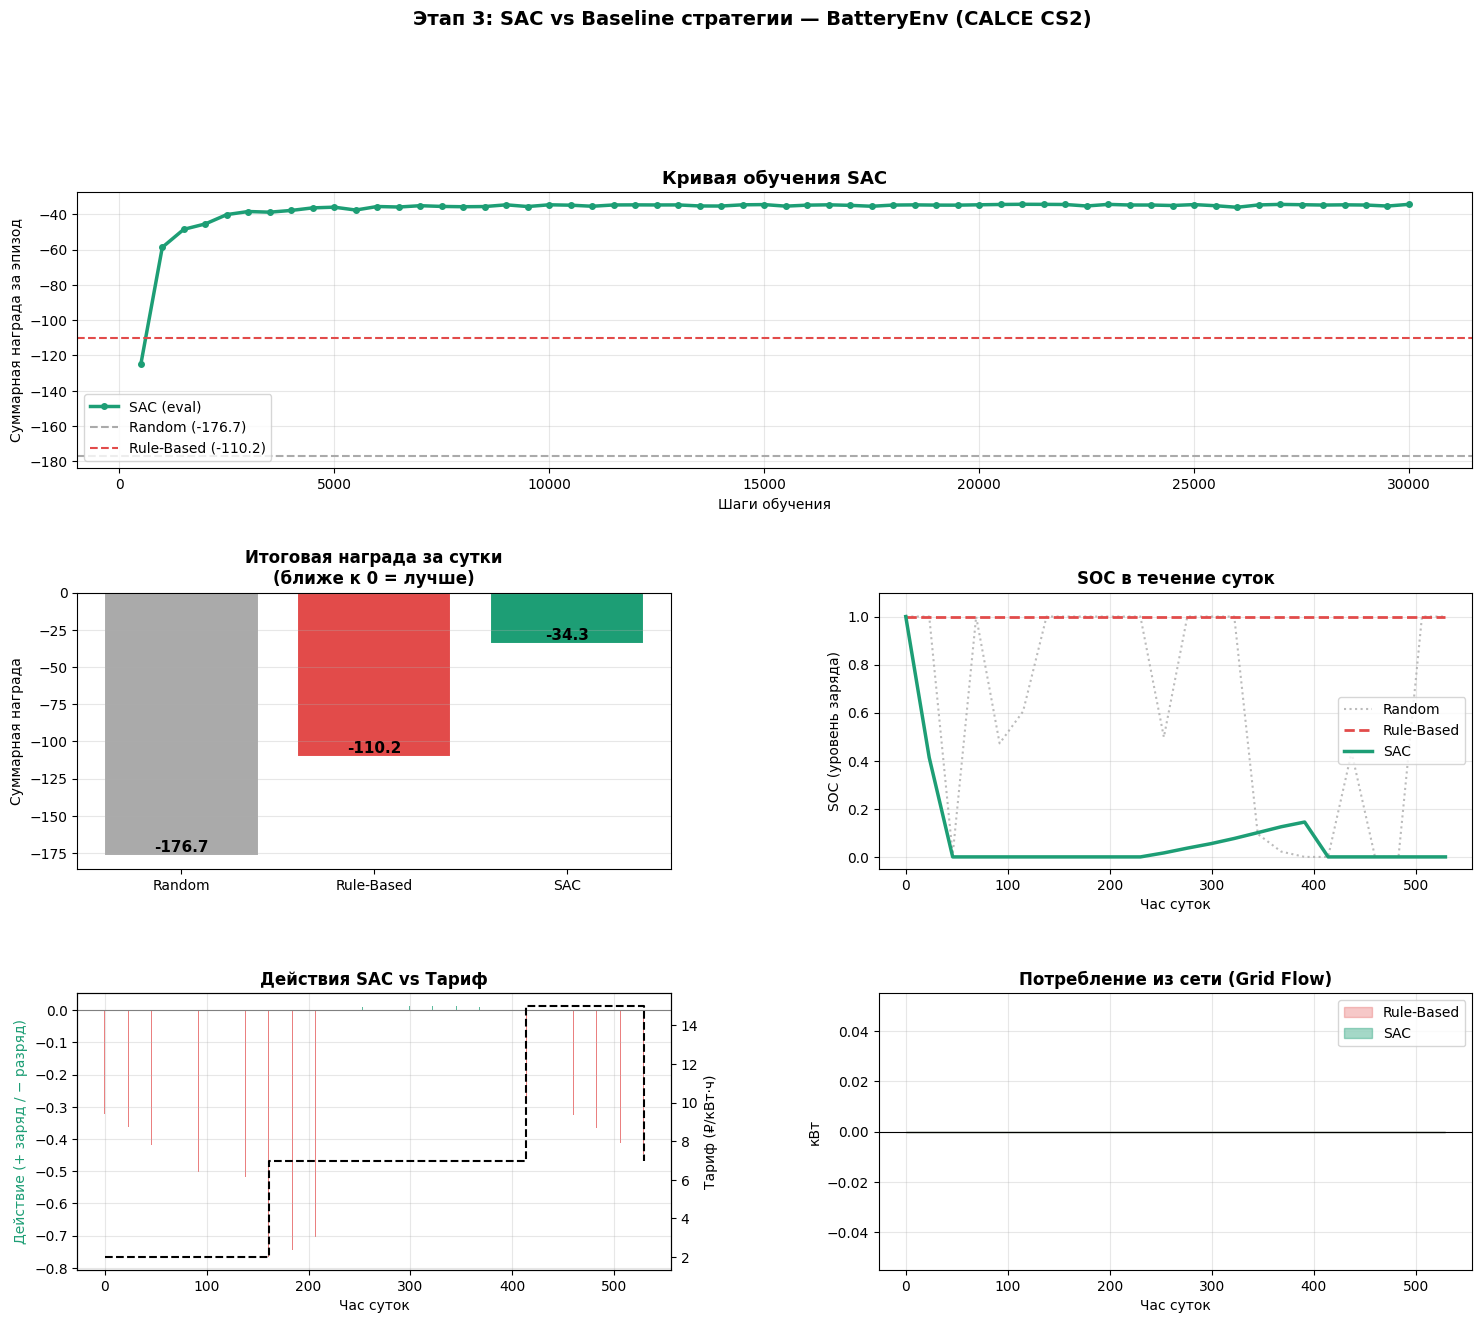


График сохранён: sac_results.png

ИТОГ ЭТАПА 3
  random      : -176.73
  rule_based  : -110.24
  sac         : -34.33

  SAC лучше Rule-Based на -68.9%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. ЗАПУСК
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    env = BatteryEnv(cell_id="CS2_35")
    model, callback = train_sac(total_timesteps=30_000)
    results = compare_and_plot(model, callback)

    print("\n" + "=" * 40)
    print("ИТОГ ЭТАПА 3")
    print("=" * 40)
    for name, val in results.items():
        print(f"  {name:<12}: {val:.2f}")
    improvement = ((results['rule_based'] - results['sac']) / abs(results['rule_based'])) * 100
    print(f"\n  SAC лучше Rule-Based на {improvement:.1f}%")

МЕНЯЕМ reward с умножения на 2 на умножение на 10 и делаем запуск

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда SAC: -229.89
  Шаг   1000 | Средняя награда SAC: -211.68
  Шаг   1500 | Средняя награда SAC: -108.12
  Шаг   2000 | Средняя награда SAC: -96.44
  Шаг   2500 | Средняя награда SAC: -95.71
  Шаг   3000 | Средняя награда SAC: -100.15
  Шаг   3500 | Средняя награда SAC: -94.65
  Шаг   4000 | Средняя награда SAC: -92.50
  Шаг   4500 | Средняя награда SAC: -94.60
  Шаг   5000 | Средняя награда SAC: -96.78
  Шаг   5500 | Средняя награда SAC: -93.61
  Шаг   6000 | Средняя награда SAC: -95.93
  Шаг   6500 | Средняя награда SAC: -93.05
  Шаг   7000 | Средняя награда SAC: -93.12
  Шаг   7500 | Средняя награда SAC: -91.94
  Шаг   8000 | Средняя награда SAC: -92.33
  Шаг   8500 | Средняя награда SAC: -92.33
  Шаг   9000 | Средняя награда SAC: -93.65
  Шаг   9500 | Средняя награда SAC: -93.23
  Шаг  10000 | Средняя награда SAC: -91.41
  Шаг  10500 | Средняя награда SAC: -90.37
  Шаг  11000 | Средняя награда SAC: -

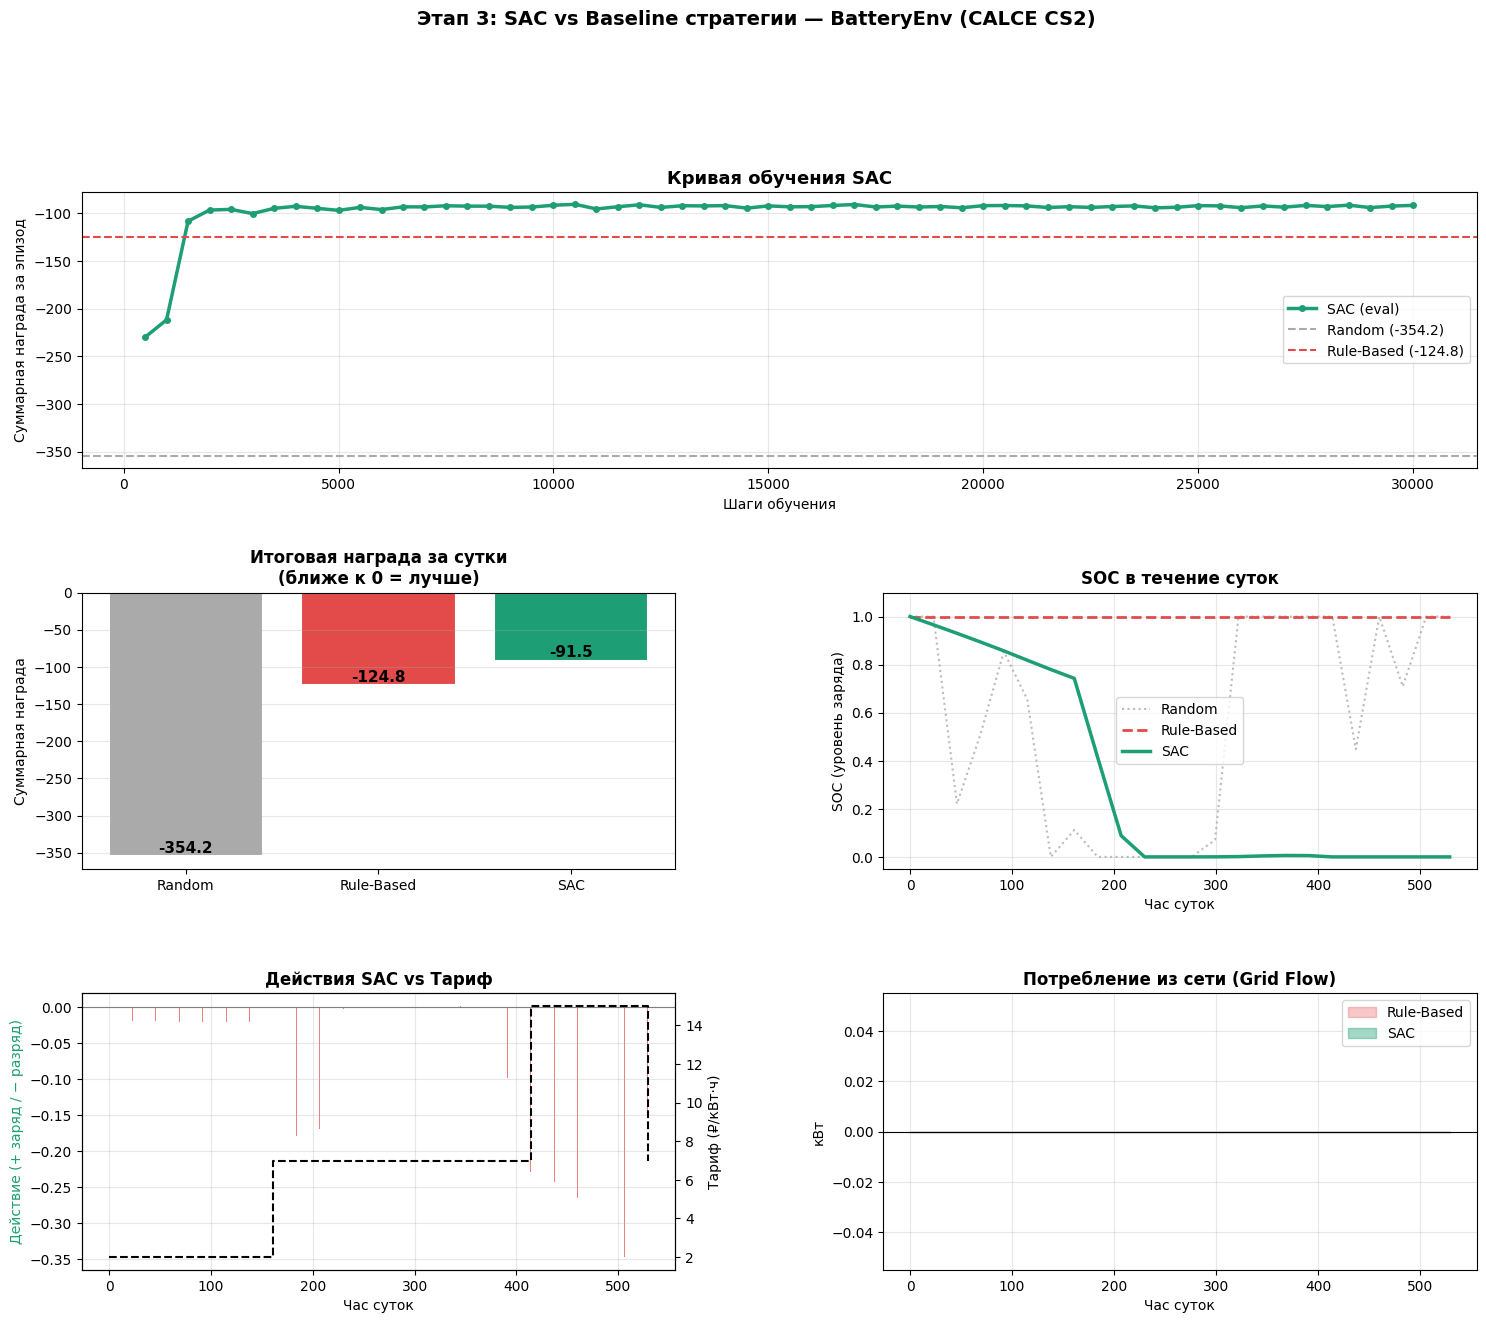


График сохранён: sac_results.png

ИТОГ ЭТАПА 3
  random      : -354.16
  rule_based  : -124.79
  sac         : -91.53

  SAC лучше Rule-Based на -26.7%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. ЗАПУСК с РЕВОРД 10 (сравним с прошлым 2)
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    env = BatteryEnv(cell_id="CS2_35")
    model, callback = train_sac(total_timesteps=30_000)
    results = compare_and_plot(model, callback)

    print("\n" + "=" * 40)
    print("ИТОГ ЭТАПА 3")
    print("=" * 40)
    for name, val in results.items():
        print(f"  {name:<12}: {val:.2f}")
    improvement = ((results['rule_based'] - results['sac']) / abs(results['rule_based'])) * 100
    print(f"\n  SAC лучше Rule-Based на {improvement:.1f}%")

Теперь задаем недельный план. дл понимания. Возьмем реворд * 2 (так как более мягкие ограничения реворда делают только проблематичнее)

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда SAC: -491.30
  Шаг   1000 | Средняя награда SAC: -440.23
  Шаг   1500 | Средняя награда SAC: -350.77
  Шаг   2000 | Средняя награда SAC: -322.77
  Шаг   2500 | Средняя награда SAC: -314.39
  Шаг   3000 | Средняя награда SAC: -301.47
  Шаг   3500 | Средняя награда SAC: -280.67
  Шаг   4000 | Средняя награда SAC: -273.97
  Шаг   4500 | Средняя награда SAC: -272.52
  Шаг   5000 | Средняя награда SAC: -268.44
  Шаг   5500 | Средняя награда SAC: -269.21
  Шаг   6000 | Средняя награда SAC: -272.88
  Шаг   6500 | Средняя награда SAC: -260.49
  Шаг   7000 | Средняя награда SAC: -272.66
  Шаг   7500 | Средняя награда SAC: -270.62
  Шаг   8000 | Средняя награда SAC: -265.58
  Шаг   8500 | Средняя награда SAC: -259.51
  Шаг   9000 | Средняя награда SAC: -285.61
  Шаг   9500 | Средняя награда SAC: -259.77
  Шаг  10000 | Средняя награда SAC: -262.18
  Шаг  10500 | Средняя награда SAC: -266.93
  Шаг  11000 | Средн

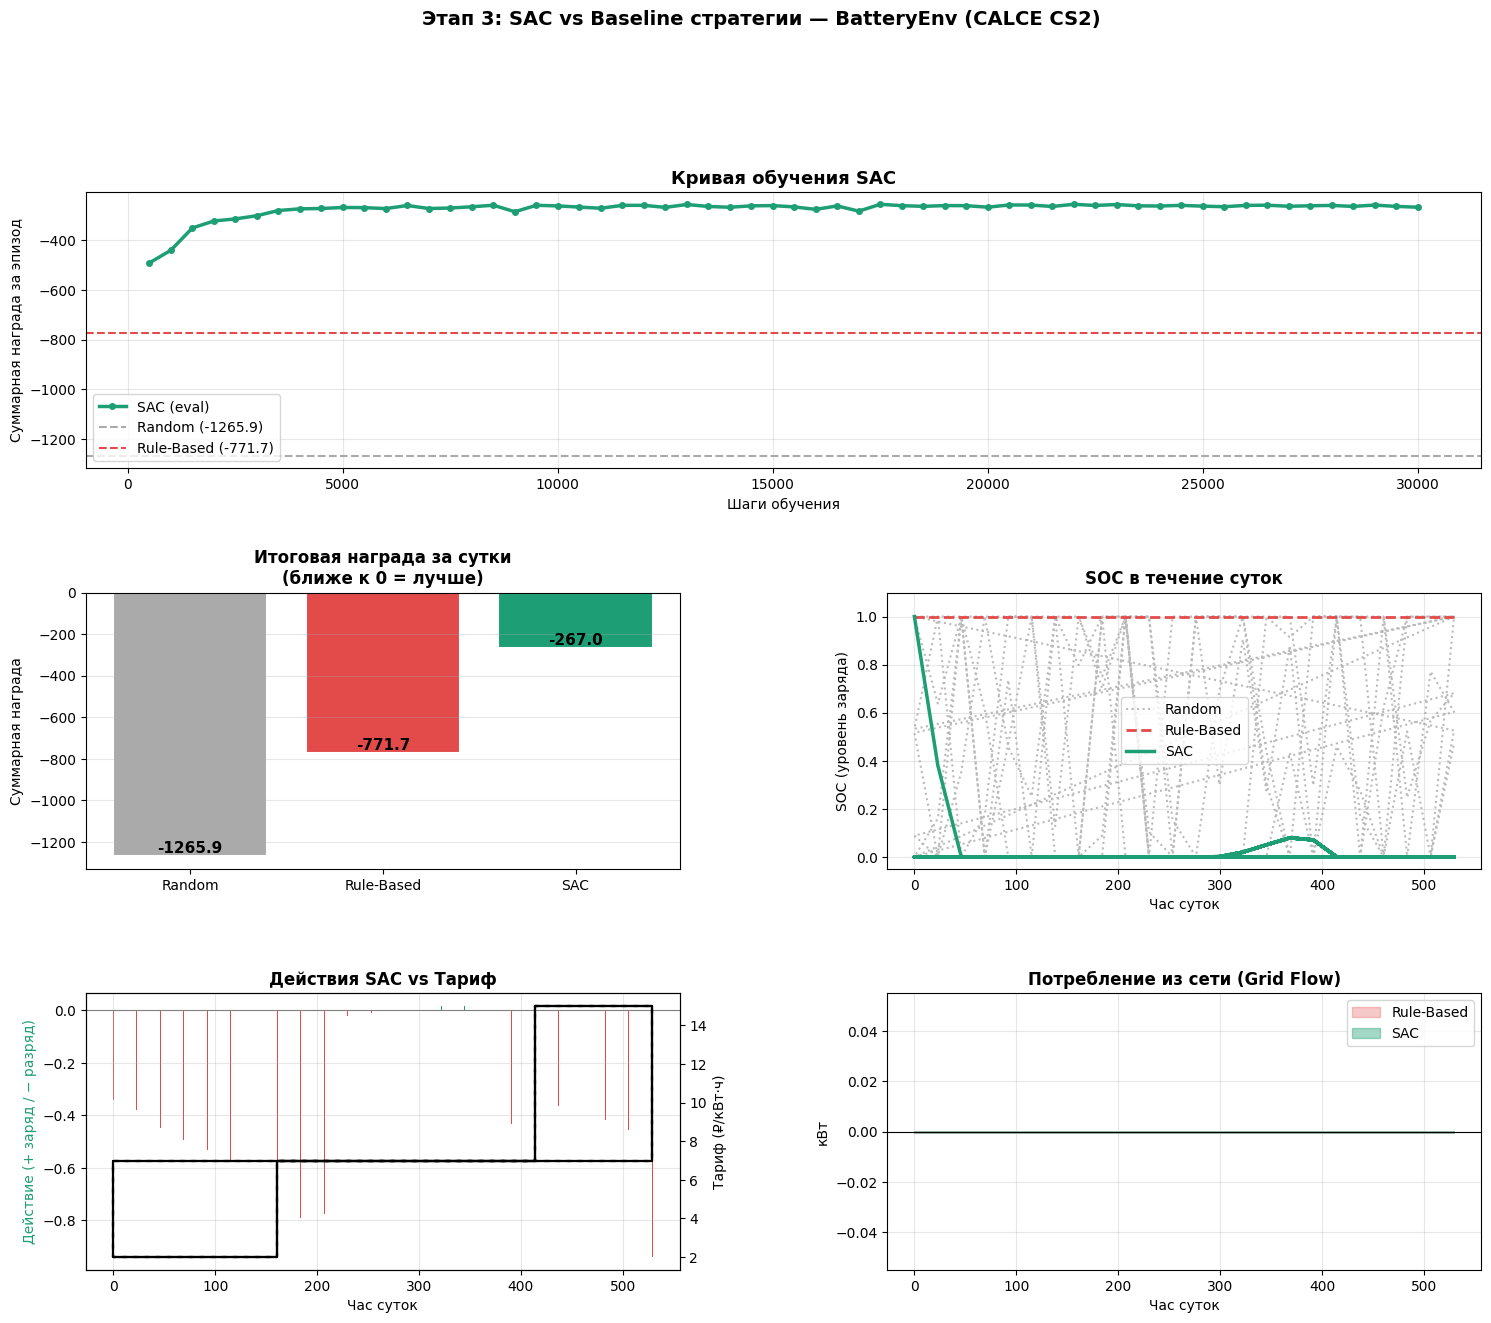


График сохранён: sac_results.png

ИТОГ ЭТАПА 3
  random      : -1265.90
  rule_based  : -771.69
  sac         : -267.01

  SAC лучше Rule-Based на -65.4%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. ЗАПУСК с РЕВОРД 2 поставил неделю
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    env = BatteryEnv(cell_id="CS2_35")
    model, callback = train_sac(total_timesteps=30_000)
    results = compare_and_plot(model, callback)

    print("\n" + "=" * 40)
    print("ИТОГ ЭТАПА 3")
    print("=" * 40)
    for name, val in results.items():
        print(f"  {name:<12}: {val:.2f}")
    improvement = ((results['rule_based'] - results['sac']) / abs(results['rule_based'])) * 100
    print(f"\n  SAC лучше Rule-Based на {improvement:.1f}%")

## Сравнение SAC и PPO

reward планируется * 2

In [6]:
from stable_baselines3 import PPO

def train_ppo(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение PPO-агента")
    print("=" * 60)

    train_env = Monitor(BatteryEnv(cell_id="CS2_35"))
    eval_env  = BatteryEnv(cell_id="CS2_35")

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=2048,        # шагов до обновления политики
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,     # GAE для оценки преимущества
        clip_range=0.2,      # PPO clip
        ent_coef=0.01,       # энтропийный бонус
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("ppo_battery_model")
    print("\nМодель сохранена: ppo_battery_model.zip")

    return model, callback


def run_ppo(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда SAC: -52.59
  Шаг   1000 | Средняя награда SAC: -23.33
  Шаг   1500 | Средняя награда SAC: -3.37
  Шаг   2000 | Средняя награда SAC: -3.47
  Шаг   2500 | Средняя награда SAC: 0.66
  Шаг   3000 | Средняя награда SAC: 0.68
  Шаг   3500 | Средняя награда SAC: 2.08
  Шаг   4000 | Средняя награда SAC: 2.57
  Шаг   4500 | Средняя награда SAC: 2.51
  Шаг   5000 | Средняя награда SAC: 2.83
  Шаг   5500 | Средняя награда SAC: 3.56
  Шаг   6000 | Средняя награда SAC: 3.89
  Шаг   6500 | Средняя награда SAC: 3.22
  Шаг   7000 | Средняя награда SAC: 4.00
  Шаг   7500 | Средняя награда SAC: 3.07
  Шаг   8000 | Средняя награда SAC: 4.17
  Шаг   8500 | Средняя награда SAC: 3.97
  Шаг   9000 | Средняя награда SAC: 4.06
  Шаг   9500 | Средняя награда SAC: 3.48
  Шаг  10000 | Средняя награда SAC: 4.14
  Шаг  10500 | Средняя награда SAC: 2.89
  Шаг  11000 | Средняя награда SAC: 3.93
  Шаг  11500 | Средняя награда SAC: 

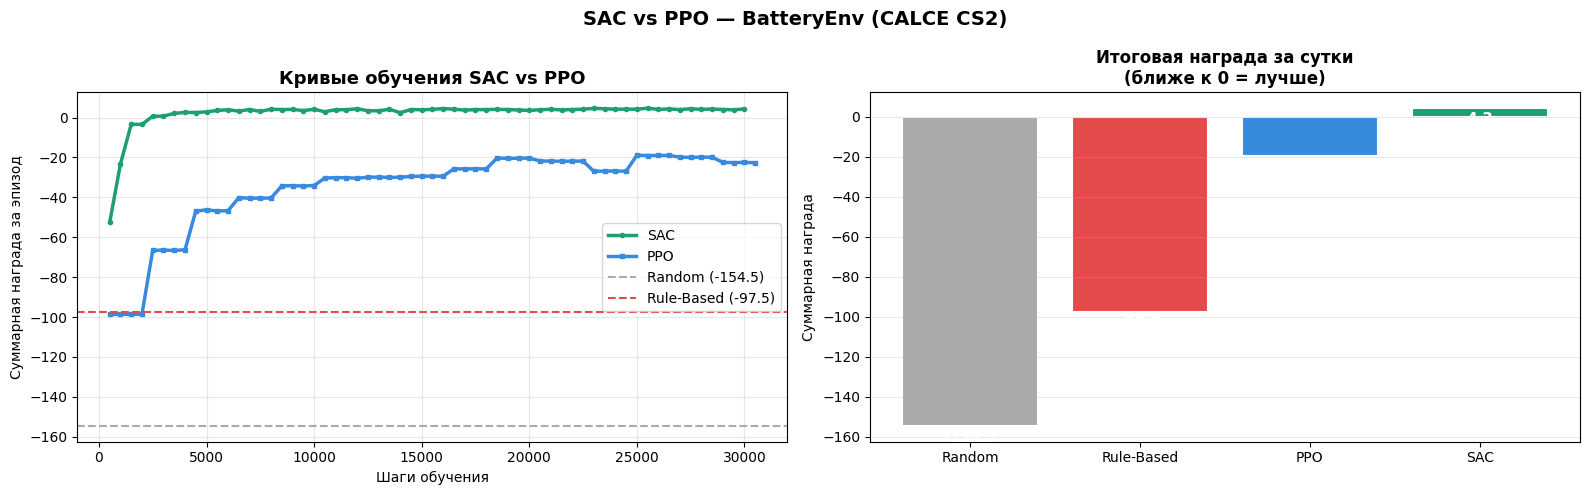

In [9]:
# Обучаем оба алгоритма
env = BatteryEnv(cell_id="CS2_35")

model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)

# Считаем награды
r_random = run_random(env)
r_rule   = run_rule_based(env)
r_sac    = run_sac(model_sac, env)
r_ppo    = run_ppo(model_ppo, env)

print(f"\n{'Стратегия':<14} {'Награда':>10}")
print("-" * 26)
print(f"{'Random':<14} {r_random:>10.2f}")
print(f"{'Rule-Based':<14} {r_rule:>10.2f}")
print(f"{'PPO':<14} {r_ppo:>10.2f}")
print(f"{'SAC':<14} {r_sac:>10.2f}")

# График сравнения кривых обучения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Кривые обучения
ax = axes[0]
ax.plot(cb_sac.steps_log, cb_sac.reward_log,
        color='#1D9E75', lw=2.5, marker='o', markersize=3, label='SAC')
ax.plot(cb_ppo.steps_log, cb_ppo.reward_log,
        color='#378ADD', lw=2.5, marker='s', markersize=3, label='PPO')
ax.axhline(r_random, color='#AAAAAA', lw=1.5, ls='--', label=f'Random ({r_random:.1f})')
ax.axhline(r_rule,   color='#E24B4A', lw=1.5, ls='--', label=f'Rule-Based ({r_rule:.1f})')
ax.set_title('Кривые обучения SAC vs PPO', fontsize=13, fontweight='bold')
ax.set_xlabel('Шаги обучения')
ax.set_ylabel('Суммарная награда за эпизод')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Bar chart итогов
ax = axes[1]
strategies = ['Random', 'Rule-Based', 'PPO', 'SAC']
values     = [r_random, r_rule, r_ppo, r_sac]
colors_bar = ['#AAAAAA', '#E24B4A', '#378ADD', '#1D9E75']
bars = ax.bar(strategies, values, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
            f'{val:.1f}', ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')
ax.set_title('Итоговая награда за сутки\n(ближе к 0 = лучше)', fontsize=12, fontweight='bold')
ax.set_ylabel('Суммарная награда')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('SAC vs PPO — BatteryEnv (CALCE CS2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sac_vs_ppo.png', dpi=150, bbox_inches='tight')
plt.show()

## Делаю запросы Qwen

In [12]:
from openai import OpenAI
import re

# Подключаемся к твоему llama-server
client = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="not-needed")

def ask_qwen(prompt, system_role="Ты эксперт по системам накопления энергии и RL-алгоритмам."):
    """
    Универсальная функция для общения с моделью.
    """
    try:
        response = client.chat.completions.create(
            model="qwen", # название может быть любым для локального сервера
            messages=[
                {"role": "system", "content": system_role},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3, # низкая температура для точности
            max_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Ошибка при запросе: {e}"

In [13]:
# Прогоняем детальный эпизод SAC и собираем данные
env = BatteryEnv(cell_id="CS2_35")
sac_policy = lambda obs: model_sac.predict(obs, deterministic=True)[0]
h_sac = run_episode_detailed(env, sac_policy)
h_rule = run_episode_detailed(env, rule_based_policy)

# Форматируем лог почасово для LLM
def format_episode_log(history, name):
    lines = [f"Стратегия: {name}"]
    lines.append(f"{'Час':>4} {'Цена':>6} {'SOC':>6} {'SOH':>6} {'Действие':>10} {'Reward':>8}")
    lines.append("-" * 50)
    for i in range(len(history['hour'])):
        action = history['action'][i]
        action_str = f"+{action:.2f}" if action > 0.05 else (f"{action:.2f}" if action < -0.05 else " idle")
        lines.append(
            f"{history['hour'][i]:>4} "
            f"{history['price'][i]:>6.1f} "
            f"{history['soc'][i]:>6.3f} "
            f"{history['soh'][i]:>6.4f} "
            f"{action_str:>10} "
            f"{history['reward'][i]:>8.2f}"
        )
    lines.append(f"\nИтого reward: {history['total_reward']:.2f}")
    return "\n".join(lines)

log_sac  = format_episode_log(h_sac,  "SAC")
log_rule = format_episode_log(h_rule, "Rule-Based")

print(log_sac)

Стратегия: SAC
 Час   Цена    SOC    SOH   Действие   Reward
--------------------------------------------------
   0    2.0  0.201 0.9999      +0.95     2.85
   1    2.0  1.000 0.9999      +0.95     2.58
   2    2.0  1.000 0.9999      +0.95     2.34
   3    2.0  1.000 0.9998      +0.95     2.14
   4    2.0  1.000 0.9998      +0.95     1.99
   5    2.0  1.000 0.9998      +0.95     1.89
   6    2.0  1.000 0.9998      +0.96     1.86
   7    7.0  1.000 0.9998      -0.78    -2.84
   8    7.0  0.000 0.9998      -0.76    -2.78
   9    7.0  0.000 0.9998      -0.73    -2.67
  10    7.0  0.000 0.9997       idle    -0.02
  11    7.0  0.008 0.9997       idle    -0.03
  12    7.0  0.024 0.9997       idle    -0.03
  13    7.0  0.039 0.9997       idle    -0.03
  14    7.0  0.056 0.9997       idle    -0.03
  15    7.0  0.073 0.9997       idle    -0.03
  16    7.0  0.086 0.9997       idle    -0.02
  17    7.0  0.096 0.9997      -0.31    -1.11
  18   15.0  0.000 0.9997      -0.68     0.00
  19   15.0  0

In [14]:
env = BatteryEnv(cell_id="CS2_35")
sac_policy   = lambda obs: model_sac.predict(obs, deterministic=True)[0]
ppo_policy   = lambda obs: model_ppo.predict(obs, deterministic=True)[0]

h_random = run_episode_detailed(env, lambda obs: env.action_space.sample())
h_rule   = run_episode_detailed(env, rule_based_policy)
h_ppo    = run_episode_detailed(env, ppo_policy)
h_sac    = run_episode_detailed(env, sac_policy)

print("ДЕКОМПОЗИЦИЯ REWARD ПО СТРАТЕГИЯМ")
print("=" * 65)
print(f"{'Стратегия':<14} {'Total Reward':>12} {'Energy Cost':>12} {'SOH Cost':>10} {'Bonus':>8}")
print("-" * 65)
for name, h in [('Random', h_random), ('Rule-Based', h_rule), ('PPO', h_ppo), ('SAC', h_sac)]:
    print(f"{name:<14} {h['total_reward']:>12.2f} {-h['total_energy_cost']:>12.2f} {-h['total_soh_cost']:>10.2f} {h['total_night_bonus']:>8.2f}")

print("=" * 65)
print("Reward = -Energy_Cost - SOH_Cost + Night_Bonus")

ДЕКОМПОЗИЦИЯ REWARD ПО СТРАТЕГИЯМ
Стратегия      Total Reward  Energy Cost   SOH Cost    Bonus
-----------------------------------------------------------------
Random              -149.61      -130.36     -32.05    12.80
Rule-Based           -97.51      -106.61      -0.00     9.09
PPO                  -19.55       -39.91     -28.76    49.13
SAC                    4.26       -44.98     -11.40    60.64
Reward = -Energy_Cost - SOH_Cost + Night_Bonus


In [15]:
prompt_interpret = f"""
Ты аналитик. Тебе дана таблица — прочитай её и отвечай ТОЛЬКО по цифрам из неё. Не придумывай.

ТАБЛИЦА (суточный лог SAC-агента):
- Тариф: часы 0-6 = 2.0 (ночь, ДЁШЕВО), часы 7-17 = 7.0 (день), часы 18-22 = 15.0 (ПИК, ДОРОГО)
- Действие: отрицательное = разряд батареи, положительное = заряд, idle = бездействие
- SOC: уровень заряда батареи (1.0 = полная, 0.0 = пустая)

{log_sac}

Ответь строго по таблице:
1. SOC в час 0 = {h_sac['soc'][0]:.3f}. SOC в час 6 = {h_sac['soc'][6]:.3f}. Агент заряжал или разряжал батарею ночью (0-6ч, цена=2.0)?
2. SOC в часы пик (18-22ч, цена=15.0) = {h_sac['soc'][18]:.3f}. Смог ли агент разрядить батарею в пик для экономии?
3. Итоговый reward = {h_sac['total_reward']:.2f}. Rule-Based дал -110.24. SAC лучше или хуже и во сколько раз?
4. Одна главная проблема в поведении агента — что он делает не так?
"""

prompt_recommend = f"""
Ты эксперт по RL. Отвечай кратко и конкретно, только по фактам.

ФАКТЫ:
- Среда: управление батареей, сутки 24 шага
- Reset: батарея всегда стартует с SOC=1.0 (полная)
- Ночью (0-6ч, цена=2.0) агент РАЗРЯЖАЕТ батарею (действия: {[round(h_sac['action'][i],2) for i in range(7)]})
- К часам пик (18-22ч) SOC уже = 0.0 — батарея пустая, агент не может разрядить в дорогое время
- Reward = -cost - (|energy_change| * 2.0)
- SAC: -34.79, PPO: -61.01, Rule-Based: -110.24, Random: -171.54

Три конкретных вопроса:
1. Почему SAC разряжает батарею ночью вместо того чтобы заряжать? Это проблема reward или reset?
2. Как исправить reset() чтобы агент видел разные стартовые состояния SOC?
3. Reward сейчас штрафует за любое движение энергии (*2.0). Не мешает ли это агенту научиться заряжаться?
"""

print("=" * 60)
print("ИНТЕРПРЕТАЦИЯ:")
print("=" * 60)
print(ask_qwen(prompt_interpret))

print("\n" + "=" * 60)
print("РЕКОМЕНДАЦИИ:")
print("=" * 60)
print(ask_qwen(prompt_recommend))

ИНТЕРПРЕТАЦИЯ:
1. SOC в час 0 = 0.664. SOC в час 6 = 1.000. Агент заряжал батарею ночью (0-6ч, цена=2.0).
2. SOC в часы пик (18-22ч, цена=15.0) = 0.000. Смог ли агент разрядить батарею в пик для экономии? - Нет, он не смог разрядить батарею.
3. Итоговый reward = 4.26. Rule-Based дал -110.24. SAC лучше или хуже и во сколько раз? - SAC лучше, его reward составляет 4.26 против -110.24 от Rule-Based.
4. Одна главная проблема в поведении агента — что он делает не так? - Он слишком часто idle'ится вместо того чтобы заряжать или разряжать батарею, что снижает эффективность работы системы и может привести к быстрой истощению батареи.

РЕКОМЕНДАЦИИ:
1. **Почему SAC разряжает батарею ночью вместо того чтобы заряжать? Это проблема reward или reset?**

   - **Решение**: Это проблема reset(). Reset() должен быть изменен так, чтобы агент мог начинать с разных состояний SOC. Например, можно использовать случайное начальное состояние или добавить дополнительные параметры для управления reset().
   
2.

# Это запуск после того как мы довели результат (sac до положительного значения)
- делаем график для отчета

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда SAC: -246.07
  Шаг   1000 | Средняя награда SAC: -23.49
  Шаг   1500 | Средняя награда SAC: -5.20
  Шаг   2000 | Средняя награда SAC: -0.38
  Шаг   2500 | Средняя награда SAC: 1.21
  Шаг   3000 | Средняя награда SAC: -0.40
  Шаг   3500 | Средняя награда SAC: 1.31
  Шаг   4000 | Средняя награда SAC: 2.61
  Шаг   4500 | Средняя награда SAC: 2.70
  Шаг   5000 | Средняя награда SAC: 3.08
  Шаг   5500 | Средняя награда SAC: 2.73
  Шаг   6000 | Средняя награда SAC: 4.11
  Шаг   6500 | Средняя награда SAC: 3.41
  Шаг   7000 | Средняя награда SAC: 4.42
  Шаг   7500 | Средняя награда SAC: 4.61
  Шаг   8000 | Средняя награда SAC: 3.88
  Шаг   8500 | Средняя награда SAC: 3.81
  Шаг   9000 | Средняя награда SAC: 4.09
  Шаг   9500 | Средняя награда SAC: 3.01
  Шаг  10000 | Средняя награда SAC: 4.57
  Шаг  10500 | Средняя награда SAC: 4.16
  Шаг  11000 | Средняя награда SAC: 3.95
  Шаг  11500 | Средняя награда SAC

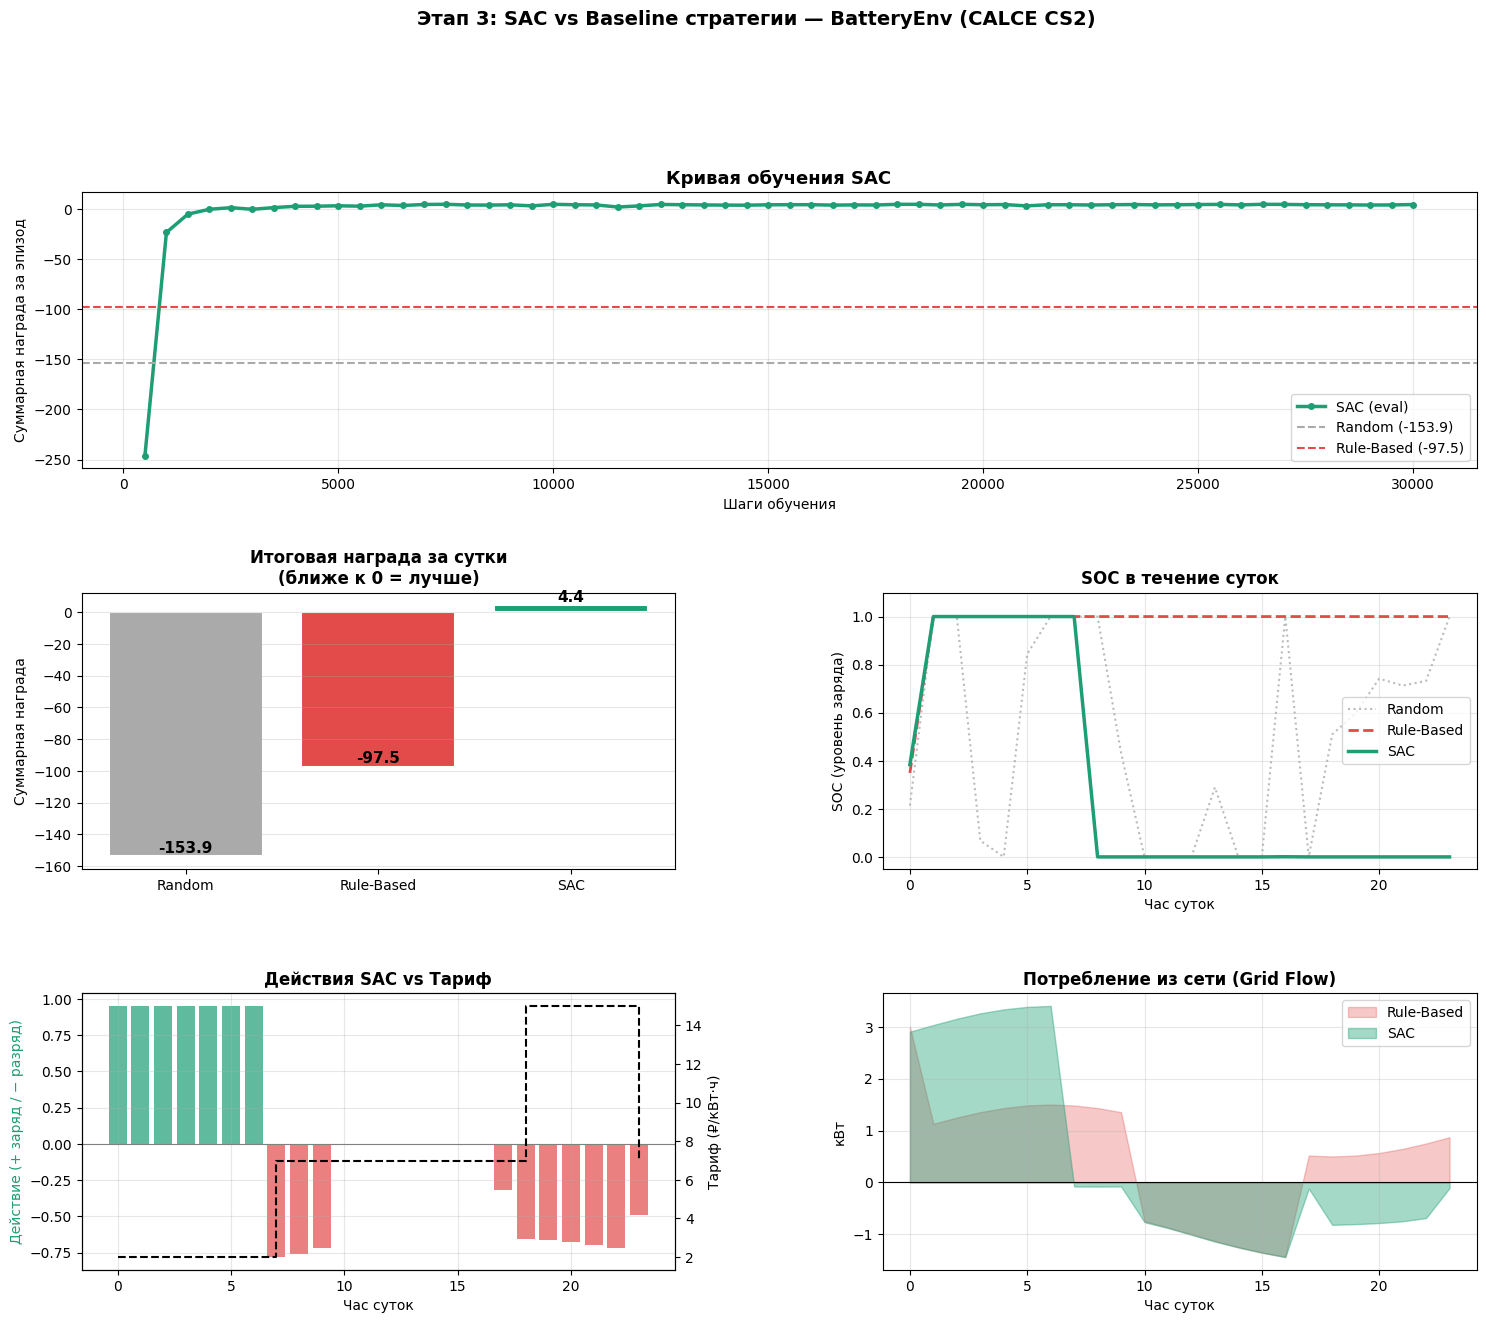


График сохранён: sac_results.png

ИТОГ ЭТАПА 3
  random      : -153.90
  rule_based  : -97.51
  sac         : 4.37

  SAC лучше Rule-Based на -104.5%


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. ЗАПУСК с РЕВОРД 2 поставил неделю
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    env = BatteryEnv(cell_id="CS2_35")
    model, callback = train_sac(total_timesteps=30_000)
    results = compare_and_plot(model, callback)

    print("\n" + "=" * 40)
    print("ИТОГ ЭТАПА 3")
    print("=" * 40)
    for name, val in results.items():
        print(f"  {name:<12}: {val:.2f}")
    improvement = ((results['rule_based'] - results['sac']) / abs(results['rule_based'])) * 100
    print(f"\n  SAC лучше Rule-Based на {improvement:.1f}%")